In [4]:
import geopandas as gpd
import pandas as pd
import sys
import numpy as np
sys.path.append('../src/streaming/3dep')
from get_als import get_nearest_year_product

In [5]:
bbs_surveys = pd.read_parquet('../datasets/BBS/50-StopData_Stop1_wide_commonName.parquet')

In [6]:
def find(row):
    try:
        result = get_nearest_year_product(row['Latitude'], row['Longitude'], 2026)
        assert result is not None, "No product found"
        return result
    except Exception as e:
        return {'product_name_AWS': None, 'collection_year_AWS': None, 'year_diff_AWS': None}

In [7]:
name_year_yeardiff = bbs_surveys.apply(find, axis=1)
surveys_w_als = bbs_surveys.join(pd.DataFrame.from_records(name_year_yeardiff), how='left')
surveys_w_als = surveys_w_als[surveys_w_als['product_name_AWS'].notna()]

Limit surveys to those within 3 years of the most recent ALS data point

In [8]:
year_difference = surveys_w_als['collection_year_AWS']-surveys_w_als['Year']
surveys_filtered = surveys_w_als[np.abs(year_difference) <= 3]

number of surveys per route:

<Axes: >

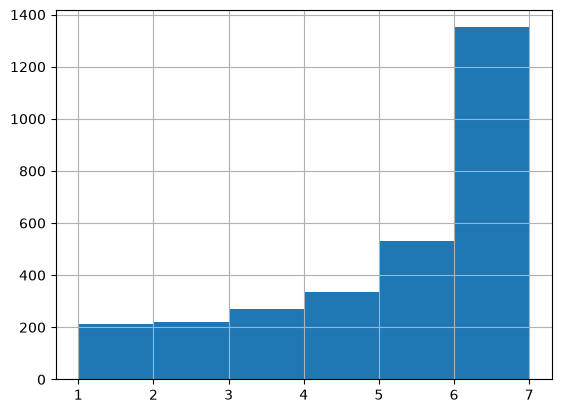

In [9]:
surveys_filtered.groupby(['RouteID']).size().hist(bins=range(1,8))

In [10]:
surveys_filtered = surveys_filtered.drop(columns=['year_diff_AWS'])
# move Latitude, Longitude, product_name_AWS, collection_year_AWS to beginning
early_cols = surveys_filtered.columns[:3].tolist()+surveys_filtered.columns[-4:].tolist()
other_cols = surveys_filtered.columns[3:-4].tolist()
surveys_filtered = surveys_filtered[early_cols + other_cols]

In [11]:
# train test split on RouteID
unique_routes = surveys_filtered['RouteID'].unique()
np.random.seed(20260909)
test_routes = np.random.choice(unique_routes, size=int(len(unique_routes)*0.5), replace=False)
surveys_filtered['test_split']=surveys_filtered['RouteID'].isin(test_routes)
surveys_filtered['test_split'].value_counts()

test_split
True     7049
False    6796
Name: count, dtype: int64

In [12]:
len(test_routes), len(unique_routes)-len(test_routes)

(1461, 1462)

In [13]:
surveys_filtered.to_parquet('../datasets/BBS/BBS_train_test.parquet', index=False)

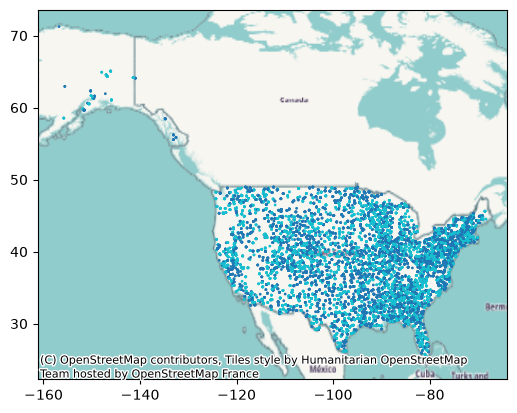

In [ ]:
# map of train/test split
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
gdf = gpd.GeoDataFrame(surveys_filtered, geometry=gpd.points_from_xy(surveys_filtered.Longitude, surveys_filtered.Latitude), crs='EPSG:4326')
gdf.plot('test_split', markersize=1)
# basemap with state borders
ctx.add_basemap(plt.gca(), crs=gdf.crs.to_string(),)
plt.savefig('../datasets/BBS/fig/matched_bbs_als_train-test.png', dpi=300, bbox_inches='tight')